# Parks attendance as a DIS tell — a quantitative teardown 🔬
### DIS vs SPY (CAGR / vol / MDD + annual-excess *t*) · a Newey-West lead-lag on DIS's *excess* return · the regime-dummy confound · a costed rotation backtest · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Parks_momentum_leads_DIS%3F: Busted](https://img.shields.io/badge/Parks_momentum_leads_DIS%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest **strictly-lagged, no-look-ahead** form of "theme-park momentum leads DIS": (H₁) DIS out-returns SPY; (H₂) release-lagged attendance growth predicts DIS's *excess* return; (H₃) a rule built on it beats buy-and-hold SPY net of cost. We find **H₁ rejected** (DIS *lags*), **H₂ rejected** (*t* ≈ 0 on the excess tape), **H₃ rejected** (the rule trails SPY).

> ⚠️ **Not investment advice — data provenance.** The attendance & ticket-price series are **hardcoded, cited, approximate** (public TEA/AECOM Theme Index — a *labelled proxy*, never a live feed), released with the report's real ~mid-following-year lag. `DIS`, `SPY` are month-end Adj Close via yfinance (as-of 2024-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#3b6fb0"

from disney_parks import data, strategy as st

HAVE_EQ = data.have_equities()
ATT = data.load_attendance()                         # hardcoded, cited, APPROXIMATE proxy
GROWTH = data.attendance_growth()
FRAME = data.build_frame() if HAVE_EQ else None
print("equity cache present:", HAVE_EQ,
      "| attendance years:", ATT.index[0].year, "->", ATT.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win_eq': '2010-01 → 2024-12', 'att_levels': {2015: 138, 2016: 140, 2017: 150, 2018: 157, 2019: 156, 2020: 47, 2021: 85, 2022: 122, 2023: 142}, 'att_growth': {2019: -1, 2020: -70, 2021: 81, 2022: 44, 2023: 16}, 'release_month': 7, 'dis_cagr': 10.41, 'dis_vol': 26.6, 'dis_sharpe': 0.5, 'dis_mdd': -57.1, 'spy_cagr': 14.14, 'spy_vol': 14.5, 'spy_sharpe': 0.99, 'spy_mdd': -23.9, 'excess_mean': -2.68, 'excess_t': -0.533, 'excess_p': 0.603, 'excess_n': 14, 'll_abs_slope': 0.00188, 'll_abs_t': 1.19, 'll_n': 137, 'll_exc_slope': 2e-05, 'll_exc_t': 0.02, 'll_price_exc_t': 0.07, 'reg_abs_cond': 16.04, 'reg_abs_base': 9.87, 'reg_abs_t': 2.04, 'reg_abs_n': 113, 'reg_exc_cond': -0.43, 'reg_exc_base': -4.77, 'reg_exc_t': 1.8, 'bt_switches': 3, 'bt_expo': 70, 'bt_gross_sharpe': 0.58, 'bt_net_sharpe': 0.578, 'bt_net_ann': 13.3, 'bt_net_vol': 23.0, 'bt_bh_dis_sharpe': 0.503, 'bt_bh_spy_sharpe': 0.987, 'ctrl_null_t': 0.6, 'ctrl_edge_t': 3.02}


equity cache present: True | attendance years: 2010 -> 2023


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Lead-lag slope of DIS **excess-of-SPY** fwd-12m return on release-lagged parks growth: **+0.00002, NW *t* = +0.02** (n=137); price-hike tell *t* = +0.07. |
| **Tradability** | `MIRAGE` | Costed rotation rule nets **Sharpe 0.578** vs buy-hold SPY **0.987**. Three stale switches; un-scalable timing. |
| **Parks momentum leads DIS?** | `BUSTED` | Theme Index prints year-Y attendance ~07/Y+1 — after Disney's quarterly segment reports. Stale by construction. |

> 💡 In plain words: DIS *lagged* the market over the window, the lagged crowd signal has essentially zero correlation with DIS beating that market, and the obvious timing rule trails an index fund. Every axis on which "parks momentum leads DIS" could survive, fails.

## 1 · The claim, steelmanned

Let the (release-lagged) parks-attendance growth be $g_t$, DIS's forward $h$-month return $r^{D}_{t\to t+h}$ and SPY's $r^{B}_{t\to t+h}$. The claim is a joint hypothesis:

- **H₁ (DIS is worth owning).** $r^{D}$ out-returns $r^{B}$ risk-adjusted over the window.
- **H₂ (the crowd leads the stock).** In $\;(r^{D}_{t\to t+h} - r^{B}_{t\to t+h}) = \alpha + \beta\, g_{t-1} + \varepsilon\;$ the slope $\beta$ is positive with a Newey-West *t* > 2 — parks momentum predicts DIS **beating the market** (a DIS-specific tell, not broad beta).
- **H₃ (it's harvestable).** A rule long DIS when $g>0$ else SPY, net of switching cost, out-Sharpes buy-and-hold SPY.

The steelman is that Parks & Experiences is Disney's largest segment and attendance is real, cited data. The test is whether the *lagged, public* signal carries **DIS-specific, net-of-cost** predictive content — or is already in the price.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, an eyeball-observable series would front-run a mega-cap — the dream of every alt-data desk. But each leg is separately falsifiable. H₁ is a **return race** on a common clock. H₂ is the crux: it must predict DIS's return *in excess of SPY*, because a signal that only tracks the broad-market regime is **not** a DIS tell — it's beta you can buy cheaper. H₃ is the **microstructure + capacity** reality: a once-a-year, six-months-late print gives you a handful of trades, not a strategy. Fail any leg and "parks momentum leads DIS" collapses to a business truism.

## 3 · How we'd know — the protocol

- **Parks series (proxy).** A hardcoded, cited, **approximate** annual attendance level (total Walt Disney Attractions, M visits) + WDW ticket price, reconstructed from public TEA/AECOM Theme Index figures. *Labelled a proxy* — its shape (2010s growth, 2020 crater, recovery) is defensible; its precise values are not a live feed.
- **Release lag (the crux).** The Theme Index for year Y is public ~07/Y+1; we step the signal onto the monthly frame at that date, then add **one** execution lag. Strict no-look-ahead.
- **Equities.** `DIS`, `SPY` month-end Adj Close (yfinance, cached). Survivorship is not a concern (two named tickers, not a screen).
- **Signal test.** (i) A small-sample annual-excess $t$ of DIS vs SPY. (ii) A **Newey-West (12-lag) HAC** $t$ of the lead-lag slope on DIS's **excess** return — the bar for `REAL` is *t* ≥ 2. (iii) A Welch regime split, absolute *and* excess, to expose the COVID-dummy confound.
- **Cost (beat 6).** Rotation rule, 1-month lag, 10 bps per switch leg; raced vs buy-and-hold DIS *and* SPY on Sharpe.
- **Positive control.** A deterministic momentum-plus-planted-edge path; the engine must stay null at edge=0 and light up at edge>0 — proof a null on the real tape is a real null.
- **What would make us say "tell":** H₂ *t* > 2 on the **excess** tape **and** the rule beats SPY net of cost. We find neither.

## 4 · The teardown

### 4a · The race — DIS vs SPY

Does the stock even reward you for the demand you can see? Month-end Adj Close, rebased.

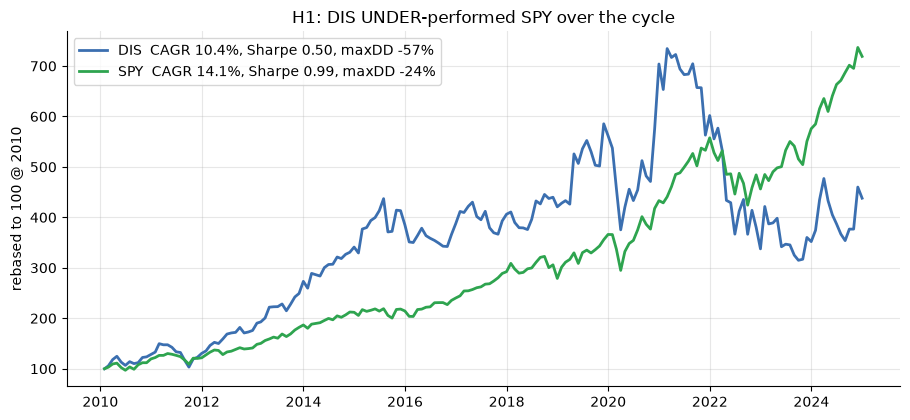

DIS: CAGR 10.41%  vol 26.6%  Sharpe 0.50  maxDD -57.1%
SPY: CAGR 14.14%  vol 14.5%  Sharpe 0.99  maxDD -23.9%
annual excess (DIS-SPY): -2.68%/yr  t=-0.533  (n=14)


In [2]:
if HAVE_EQ:
    dis, spy = FRAME['dis'], FRAME['spy']
    di, ss = st.summarize(dis), st.summarize(spy)
    ae = st.annual_excess_t(dis, spy)
    dn, sn = dis/dis.iloc[0]*100, spy/spy.iloc[0]*100; xd = dis.index
else:
    di = {'cagr':R['dis_cagr']/100,'vol':R['dis_vol']/100,'sharpe':R['dis_sharpe'],'mdd':R['dis_mdd']/100}
    ss = {'cagr':R['spy_cagr']/100,'vol':R['spy_vol']/100,'sharpe':R['spy_sharpe'],'mdd':R['spy_mdd']/100}
    ae = {'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
    xd = pd.date_range('2010-01-31', periods=180, freq='ME')
    dn = pd.Series(100*(1+R['dis_cagr']/100)**(np.arange(180)/12), index=xd)
    sn = pd.Series(100*(1+R['spy_cagr']/100)**(np.arange(180)/12), index=xd)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(xd, dn, c=BLUE, lw=2.0, label=f"DIS  CAGR {di['cagr']*100:.1f}%, Sharpe {di['sharpe']:.2f}, maxDD {di['mdd']*100:.0f}%")
ax.plot(xd, sn, c=GREEN, lw=2.0, label=f"SPY  CAGR {ss['cagr']*100:.1f}%, Sharpe {ss['sharpe']:.2f}, maxDD {ss['mdd']*100:.0f}%")
ax.set_ylabel('rebased to 100 @ 2010'); ax.set_title('H1: DIS UNDER-performed SPY over the cycle'); ax.legend()
plt.tight_layout(); plt.show()
print(f"DIS: CAGR {di['cagr']*100:.2f}%  vol {di['vol']*100:.1f}%  Sharpe {di['sharpe']:.2f}  maxDD {di['mdd']*100:.1f}%")
print(f"SPY: CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  Sharpe {ss['sharpe']:.2f}  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (DIS-SPY): {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: DIS compounded at **10.4%** vs SPY's **14.1%**, at ~twice the vol and with a **-57%** drawdown. The mean annual excess is **-2.7%/yr, *t* = -0.53** (n=14) — a losing point estimate, indistinct from zero. H₁ rejected: the stock did not reward the visible demand.

### 4b · The lead-lag — does the crowd predict DIS *beating the market*?

Newey-West (12-lag) regression of DIS's forward-12m return on the release-lagged attendance growth. We run it two ways: on DIS's **raw** return, and on its **excess of SPY** — the return a genuine DIS tell must move. `REAL` needs $t \ge 2$ on the excess.

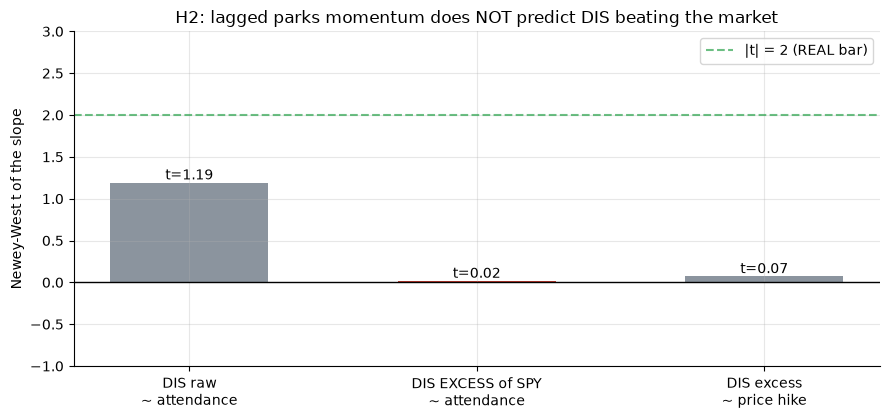

DIS raw ~ attendance   : t=+1.19
DIS EXCESS ~ attendance: t=+0.02   <- the DIS-specific tell (a mechanical zero)
DIS excess ~ price hike: t=+0.07


In [3]:
if HAVE_EQ:
    lla = st.lead_lag(FRAME, 'pg', 12, 1, excess=False)
    lle = st.lead_lag(FRAME, 'pg', 12, 1, excess=True)
    llp = st.lead_lag(FRAME, 'ph', 12, 1, excess=True)
    ts = [lla['t'], lle['t'], llp['t']]
else:
    ts = [R['ll_abs_t'], R['ll_exc_t'], R['ll_price_exc_t']]
labels = ['DIS raw\n~ attendance', 'DIS EXCESS of SPY\n~ attendance', 'DIS excess\n~ price hike']
cols = [GREY, RED, GREY]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
b = ax.bar(labels, ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=GREEN, alpha=.7, label='|t| = 2 (REAL bar)'); ax.axhline(-2, ls='--', c=GREEN, alpha=.7)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Newey-West t of the slope'); ax.set_ylim(-1, 3)
for bb,v in zip(b,ts): ax.annotate(f't={v:.2f}',(bb.get_x()+bb.get_width()/2,v),ha='center',va='bottom')
ax.set_title('H2: lagged parks momentum does NOT predict DIS beating the market'); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(f'DIS raw ~ attendance   : t={ts[0]:+.2f}')
print(f'DIS EXCESS ~ attendance: t={ts[1]:+.2f}   <- the DIS-specific tell (a mechanical zero)')
print(f'DIS excess ~ price hike: t={ts[2]:+.2f}')

> 💡 In plain words: on the return that *is* the claim — DIS beating the S&P — the slope is **+0.00002** with *t* = **+0.02**. That is as close to a mechanical zero as this desk prints. The pricing-power tell is the same nothing (*t*=+0.07). Even DIS's *raw* return only reaches *t*=+1.19 — sub-2, and that's before benchmarking. **H₂ rejected.**

### 4c · The one number that flirts with 2 — and why it's a confound

A believer will reach for a **regime split**: DIS's forward return when parks momentum is positive vs the base rate. On *absolute* return that Welch *t* touches 2 — so let's show exactly why that's the COVID regime, not a tell, by re-running it on the **excess** return.

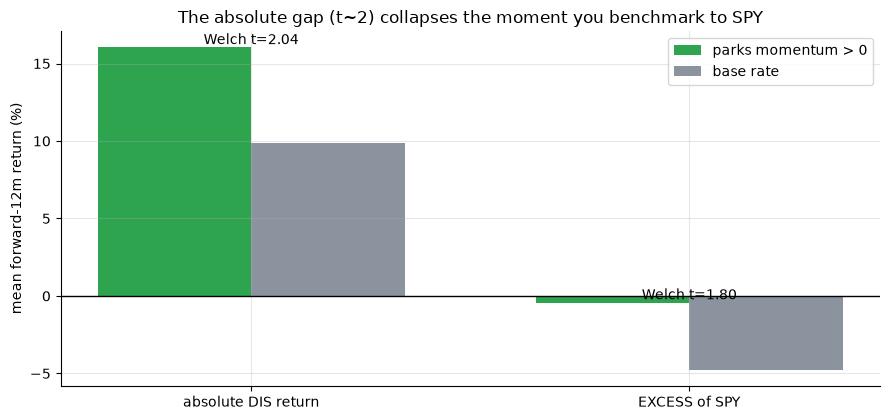

absolute DIS return   : cond +16.04%  base +9.87%  Welch t=+2.04
EXCESS of SPY         : cond -0.43%  base -4.77%  Welch t=+1.80


In [4]:
if HAVE_EQ:
    ra = st.regime_split(FRAME, 12, 1, excess=False)
    re = st.regime_split(FRAME, 12, 1, excess=True)
    pairs = [('absolute DIS return', ra['cond_mean']*100, ra['base_mean']*100, ra['t']),
             ('EXCESS of SPY', re['cond_mean']*100, re['base_mean']*100, re['t'])]
else:
    pairs = [('absolute DIS return', R['reg_abs_cond'], R['reg_abs_base'], R['reg_abs_t']),
             ('EXCESS of SPY', R['reg_exc_cond'], R['reg_exc_base'], R['reg_exc_t'])]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(2); w=.35
ax.bar(x-w/2, [p[1] for p in pairs], w, color=GREEN, label='parks momentum > 0')
ax.bar(x+w/2, [p[2] for p in pairs], w, color=GREY, label='base rate')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([p[0] for p in pairs])
ax.set_ylabel('mean forward-12m return (%)')
for i,p in enumerate(pairs): ax.annotate(f'Welch t={p[3]:.2f}',(i, max(p[1],p[2])),ha='center',va='bottom',fontsize=10)
ax.set_title('The absolute gap (t~2) collapses the moment you benchmark to SPY'); ax.legend()
plt.tight_layout(); plt.show()
for p in pairs: print(f'{p[0]:22s}: cond {p[1]:+.2f}%  base {p[2]:+.2f}%  Welch t={p[3]:+.2f}')

> 💡 In plain words: on *absolute* return the split gives *t*=2.04 — just over the bar. But "parks momentum > 0" is essentially **"not the COVID-crater regime"** (the negative-momentum months are 2020's −70% print, public mid-2021). DIS simply had lower absolute returns around that market-wide shock. Benchmark to SPY and the gap **collapses to *t*=1.80** (sub-2); use the continuous signal and it's *t*=0.02. It's market beta wearing a parks costume — not a DIS tell.

### 4d · The microstructure & capacity reality — net of cost

The obvious rule: long DIS when release-lagged parks momentum > 0, else rotate to SPY; 1-month execution lag, 10 bps per switch leg (a DIS↔SPY swap, no borrow). Raced vs both buy-and-holds.

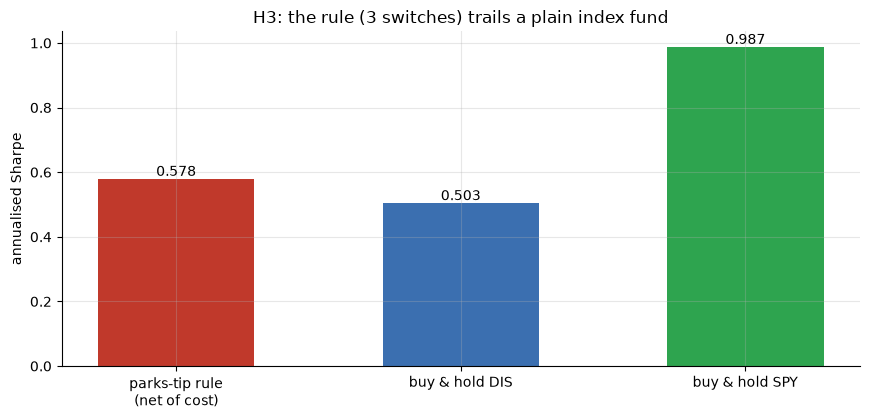

rule net Sharpe 0.578  |  buy-hold DIS 0.503  |  buy-hold SPY 0.987  (3 switches, 70% DIS)


In [5]:
if HAVE_EQ:
    bt = st.timing_backtest(FRAME, lag=1, cost_bps=10.0, hold_bench=True)
    sr = [bt['net']['sharpe'], bt['buy_hold_dis']['sharpe'], bt['buy_hold_spy']['sharpe']]
    sw, expo = bt['n_switches'], bt['exposure_dis']*100
else:
    sr = [R['bt_net_sharpe'], R['bt_bh_dis_sharpe'], R['bt_bh_spy_sharpe']]
    sw, expo = R['bt_switches'], R['bt_expo']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
cols = [RED, BLUE, GREEN]
b = ax.bar(['parks-tip rule\n(net of cost)','buy & hold DIS','buy & hold SPY'], sr, color=cols, width=.55)
for bb,v in zip(b,sr): ax.annotate(f'{v:.3f}',(bb.get_x()+bb.get_width()/2,v),ha='center',va='bottom')
ax.set_ylabel('annualised Sharpe'); ax.set_title(f'H3: the rule ({sw:.0f} switches) trails a plain index fund')
plt.tight_layout(); plt.show()
print(f'rule net Sharpe {sr[0]:.3f}  |  buy-hold DIS {sr[1]:.3f}  |  buy-hold SPY {sr[2]:.3f}  ({sw:.0f} switches, {expo:.0f}% DIS)')

> 💡 In plain words: the rule nets Sharpe **0.578** — it beats buy-and-hold *DIS* (0.503) only because it spends ~30% of the time hiding in SPY, and it **loses badly to just holding SPY (0.987)**. Its whole 'edge' is **3** stale, once-a-year rotations. **H₃ rejected** — and as *timing*, a six-months-late annual print has no capacity to be a strategy.

### 4e · Positive control — the engine recovers a planted edge

A deterministic momentum-plus-price path (seed 769): the same Newey-West lead-lag must stay null when no edge is planted and light up when one is — proving the nulls above are real, not a broken pipeline.

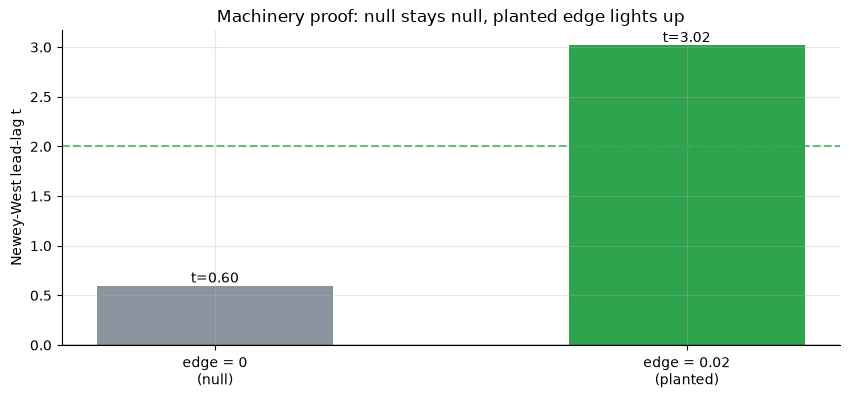

edge=0 -> t=+0.60 (must stay small)   edge=0.02 -> t=+3.02 (must light up)


In [6]:
c0 = st.control_recovers(data.synthetic(edge=0.0), 0.0)
c1 = st.control_recovers(data.synthetic(edge=0.02), 0.02)
fig, ax = plt.subplots(figsize=(8.6, 4.1))
b = ax.bar(['edge = 0\n(null)', 'edge = 0.02\n(planted)'], [c0['t'], c1['t']], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=GREEN, alpha=.7); ax.axhline(0, c='k', lw=1)
for bb,v in zip(b,[c0['t'],c1['t']]): ax.annotate(f't={v:.2f}',(bb.get_x()+bb.get_width()/2,v),ha='center',va='bottom')
ax.set_ylabel('Newey-West lead-lag t'); ax.set_title('Machinery proof: null stays null, planted edge lights up')
plt.tight_layout(); plt.show()
print(f"edge=0 -> t={c0['t']:+.2f} (must stay small)   edge=0.02 -> t={c1['t']:+.2f} (must light up)")

> 💡 In plain words: at edge=0 the engine returns *t*=+0.60 (no manufactured significance); with a planted edge, *t*=+3.02. A synthetic control is a machinery proof, never market evidence — but it certifies the `NONE`/`MIRAGE` stamps are a true null, not a pipeline that couldn't detect anything.

## 5 · The verdict

- **Signal `NONE`** — the lead-lag slope of DIS's **excess** return on release-lagged parks growth is +0.00002, NW *t* = +0.02 (n=137); the price-hike tell is *t* = +0.07. The lone |*t*| ≥ 2 (a regime dummy on *absolute* return, *t*=2.04) is a COVID/market-beta artifact that vanishes vs SPY (*t*=1.80). No robust *t* ≥ 2 for the actual claim.
- **Tradability `MIRAGE`** — the costed rotation nets Sharpe 0.578 vs buy-hold SPY 0.987; 3 stale switches, no capacity as timing.
- **Parks momentum leads DIS? `BUSTED`** — a six-months-late annual print can't front-run a stock whose quarterly segment reports already carry the same news. The visible crowd is real; the tradable edge is not.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000, 2010→2024: an S&P index fund vs the parks-tip rule (net Sharpe/CAGR from 4d) vs buy-and-hold DIS. Capacity is the second wall: the signal updates **once a year, six months late** — there is no book to scale.

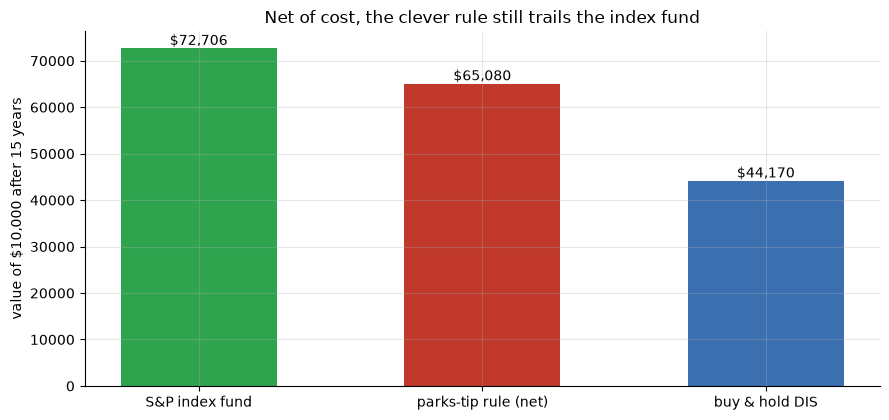

S&P index fund           $    72,706  (+14.1%/yr)
parks-tip rule (net)     $    65,080  (+13.3%/yr)
buy & hold DIS           $    44,170  (+10.4%/yr)


In [7]:
start=10_000.0; n=15
paths={'S&P index fund':R['spy_cagr']/100, 'parks-tip rule (net)':R['bt_net_ann']/100,
       'buy & hold DIS':R['dis_cagr']/100}
labels=list(paths); ends=[start*(1+g)**n for g in paths.values()]; cols=[GREEN, RED, BLUE]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(labels, ends, .55, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 15 years'); ax.set_title('Net of cost, the clever rule still trails the index fund')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f'{l:24s} ${start*(1+g)**n:>10,.0f}  ({g*100:+.1f}%/yr)')

> 💡 In plain words: the passive index fund wins outright. The rule's tiny edge over buy-and-hold DIS is entirely that it parks in SPY part-time — and it never catches SPY itself. With one stale signal a year, there is no sizing or venue that turns this into an edge. **MIRAGE** is the only honest stamp.

## 7 · Going further

- **Beat the release calendar.** Our attendance line is released on the Theme Index's real ~mid-following-year schedule. Swap in a *faster* read — Disney's own quarterly Parks & Experiences revenue, or paid satellite/mobility car-counts — and test whether *that* leads before it's priced. Being early is the entire game.
- **Per-park / attendance-vs-revenue.** Attendance ≠ profit (pricing, per-cap spend, mix). Test operating-income momentum, or split domestic vs international parks — the aggregate may hide sign.
- **The alt-data decay prior.** McLean & Pontiff and the crowding literature: a public, journalism-friendly signal is the least edgy kind ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; the attendance & ticket series are **cited, approximate proxies** released with the report's real lag. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*